In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.9 MB/s eta 0:00:00


In [ ]:
# STEP 1: LOAD CLEANED DATA
# We load the preprocessed CSV produced by the preprocessing notebook.
# The clean_text column is used as input for both sentiment models.
import pandas as pd
df = pd.read_csv('youtube_comments_preprocessedfinal.csv')

df.head()

,author,updated_at,like_count,text,video_id,public,clean_text,tokens,lemmas,processed_text
0,@doomkid1331,2026-05-23T23:42:49Z,0,"Wore my Mk4s until they broke, and exchanged t...",XbXXKhfvSF0,True,wore my mk4s until they broke and exchanged th...,"['wore', 'my', 'mk4s', 'until', 'they', 'broke...","['wear', 'mk4s', 'break', 'exchange', 'mk5', '...",wear mk4s break exchange mk5 perfect mk6
1,@TurkeyTomDeezNuts,2026-05-23T16:48:27Z,0,These have such bad reviews,XbXXKhfvSF0,True,these have such bad reviews,"['these', 'have', 'such', 'bad', 'reviews']","['bad', 'review']",bad review
2,@elevate5136,2026-05-22T04:30:00Z,0,I bought these in South Africa for my 12 hour ...,XbXXKhfvSF0,True,i bought these in south africa for my 12 hour ...,"['i', 'bought', 'these', 'in', 'south', 'afric...","['buy', 'south', 'africa', '12', 'hour', 'flig...",buy south africa 12 hour flight home absolutel...
3,@Tdizzle_91,2026-05-21T20:57:05Z,0,Can you compare these to the new collextion mo...,XbXXKhfvSF0,True,can you compare these to the new collextion mo...,"['can', 'you', 'compare', 'these', 'to', 'the'...","['compare', 'new', 'collextion', 'model', 'kno...",compare new collextion model know buy lol
4,@andrewbarf,2026-05-21T09:35:58Z,0,Excellent review Marques; all the main points ...,XbXXKhfvSF0,True,excellent review marques all the main points c...,"['excellent', 'review', 'marques', 'all', 'the...","['excellent', 'review', 'marque', 'main', 'poi...",excellent review marque main point cover waffl...


In [ ]:
# STEP 2: VADER SENTIMENT ANALYSIS
# VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based
# model designed for social media text. It produces a compound score from -1 to 1.
# Scores >= 0.05 are labelled positive, <= -0.05 negative, and the rest neutral.
# VADER is fast and requires no GPU, making it a practical baseline.
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

analyzer = SentimentIntensityAnalyzer()

tqdm.pandas()

def get_sentiment(text):
    scores = analyzer.polarity_scores(text)

    compound = scores["compound"]

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["clean_text"].progress_apply(get_sentiment)

100%|██████████| 24623/24623 [00:05<00:00, 4671.67it/s]


In [ ]:
def get_compound_score(text):
    return analyzer.polarity_scores(text)["compound"]

df["sentiment_score"] = df["clean_text"].progress_apply(get_compound_score)

100%|██████████| 24623/24623 [00:08<00:00, 2870.07it/s]


In [ ]:
print(df["sentiment"].value_counts())

sentiment
Positive    12716
Neutral      7409
Negative     4498
Name: count, dtype: int64


In [ ]:
sentiment_percentages = (
    df["sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentages)

sentiment
Positive    51.642773
Neutral     30.089753
Negative    18.267474
Name: proportion, dtype: float64


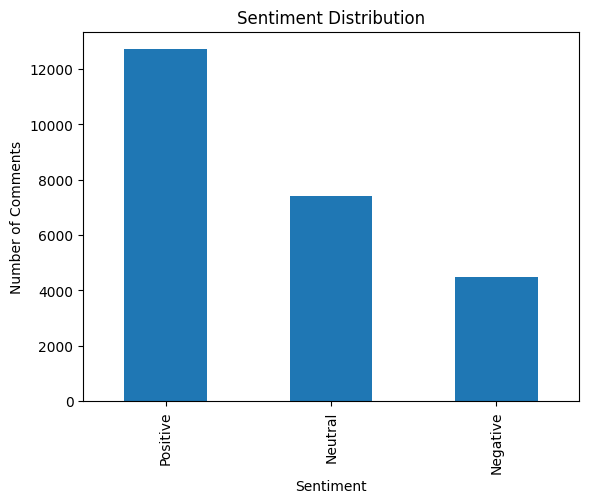

In [ ]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()

In [ ]:
df[
    ["clean_text", "sentiment"]
].sample(20)

,clean_text,sentiment
22735,which is actually the best,Positive
19622,i currently have a huawei mate 20x 72 4g but s...,Negative
3446,since headphones are mainly about listening to...,Positive
8677,yeah man i know today is april 1,Positive
15351,i knew oppo gonna win this,Positive
6716,you definitely got me on this one,Positive
7589,weather app at 210,Neutral
7969,took me around 5 mins to realize that its a ap...,Neutral
24019,id buy any of the phones as long as they are n...,Positive
14556,zte nubia z80 ultra i think is the best out there,Positive


In [ ]:
df.rename(columns={
    "sentiment":"vader_sentiment",
    "sentiment_score":"vader_score"
}, inplace=True)

In [ ]:
!pip install transformers torch tqdm

In [ ]:
from transformers import pipeline
from tqdm import tqdm
import pandas as pd

tqdm.pandas()

sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
# STEP 3: ROBERTA SENTIMENT ANALYSIS
# We use cardiffnlp/twitter-roberta-base-sentiment-latest from HuggingFace.
# This model was fine-tuned on Twitter data, which shares informal language
# characteristics with YouTube comments (abbreviations, slang, short sentences).
# It is run via the HuggingFace pipeline with truncation at 512 tokens.
# This step takes several minutes on the full dataset — GPU is recommended.
sample_df = df.sample(1000, random_state=42).copy()

def get_roberta_sentiment(text):
    result = sentiment_model(str(text))[0]
    return result["label"]

sample_df["roberta_sentiment"] = sample_df["clean_text"].progress_apply(get_roberta_sentiment)

sample_df[["clean_text", "roberta_sentiment"]].sample(10)

100%|██████████| 1000/1000 [00:10<00:00, 94.39it/s]


,clean_text,roberta_sentiment
3274,i love my senny momentums 4s how much better a...,positive
11242,nice blazer mate loved it,positive
4285,do they sound better than the airpods max and ...,positive
11866,honor x9d definetlly deserved a couple of awar...,positive
9960,i actually was shocked when samsung s23 ultra ...,positive
20614,the horrendously ugly turd shaped hole for the...,negative
18404,the best camera is not vivo x200pro but the hu...,positive
14324,honered to win no award,negative
4461,wtf sony why battery life is so bad i have sen...,negative
8309,great way to april fool,negative


In [ ]:
def get_roberta_sentiment(text):
    result = sentiment_model(str(text))[0]
    return result["label"]

df["roberta_sentiment"] = df["clean_text"].progress_apply(get_roberta_sentiment)

100%|██████████| 24623/24623 [04:09<00:00, 98.61it/s] 


In [ ]:
def get_roberta_score(text):
    result = sentiment_model(str(text))[0]
    return result["score"]

df["roberta_score"] = df["clean_text"].progress_apply(get_roberta_score)

100%|██████████| 24623/24623 [03:59<00:00, 102.76it/s]


In [ ]:
print(df["roberta_sentiment"].value_counts())

roberta_sentiment
neutral     9916
positive    8332
negative    6375
Name: count, dtype: int64


In [ ]:
print(
    (df["roberta_sentiment"].value_counts(normalize=True) * 100)
    .round(2)
)

roberta_sentiment
neutral     40.27
positive    33.84
negative    25.89
Name: proportion, dtype: float64


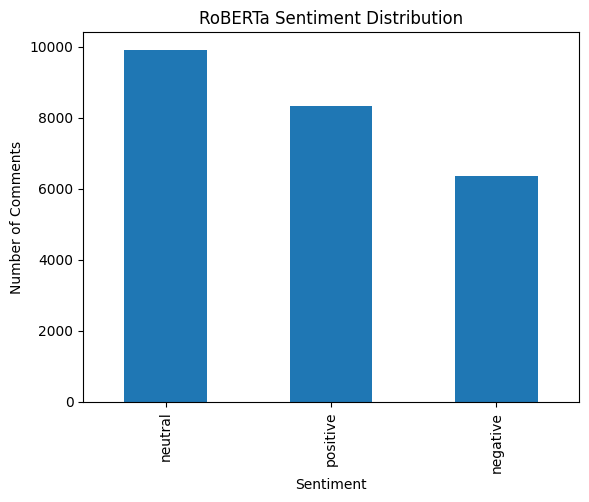

In [ ]:
import matplotlib.pyplot as plt

df["roberta_sentiment"].value_counts().plot(kind="bar")

plt.title("RoBERTa Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()

In [ ]:
df[df["roberta_sentiment"]=="positive"][
    ["clean_text","roberta_score"]
].sample(10)

,clean_text,roberta_score
10383,so happy with the s23 ultra definitely the bes...,0.988391
6897,lets all have a moment of silence for the ipho...,0.464687
21860,the nubia z70 ultra is definitely worth mentio...,0.980410
8388,he literally got me april fools good sir,0.775009
363,any other headphone better than this or this i...,0.873341
12798,best non ai phone,0.723060
17786,i am on my 4th garmin watch now the fr 35 even...,0.964897
5919,at the best compact phone i shouted no way,0.906844
7052,you got me,0.769434
17005,the apple watch ultra 2 is capped to about 2 f...,0.524678


In [ ]:
df[df["roberta_sentiment"]=="negative"][
    ["clean_text","roberta_score"]
].sample(10)

,clean_text,roberta_score
136,0419 on ur back what hell this guy is doing,0.937182
5282,hate watching vids 3 months later just to find...,0.886018
15203,why are you wearing makeup,0.550223
11897,i still feel like most of his videos award vid...,0.732761
22051,asus let us down by not releasing a smole zenf...,0.877615
15019,bro put extra bass on k90 pro max damn,0.632949
11128,i love that so many people dont get that this ...,0.512409
8352,didnt realise this was an april fools joke for...,0.733492
4447,and i still use crappy whch510 serries,0.906396
9144,i never figured out,0.527150


In [ ]:
df[df["roberta_sentiment"]=="neutral"][
    ["clean_text","roberta_score"]
].sample(10)

,clean_text,roberta_score
18218,bro wearing a suit and stands up in shorts,0.854365
7889,samsung is the ronaldo of android phones,0.548950
16360,for the money ill stick with wired bluetooth j...,0.499884
10061,i cant tell if i just watched an ad for the ss...,0.686904
12164,hi my name is john and im from south africa i ...,0.487624
814,to sleep with,0.813679
15302,i have it,0.675157
11420,hi any thoughts on the norm 2,0.922854
13805,copied mkbhd down to wearing a sports jacket,0.842342
3117,is it as fast as driving in school zones,0.820504


In [ ]:

df[
    ["clean_text", "roberta_sentiment"]
].sample(20)

,clean_text,roberta_sentiment
7559,what was the purpose of the other phones sleep...,neutral
22101,you sure youre not sponsored by vivo,neutral
12049,awards categories 0023 the glow award most imp...,positive
12066,024 glow up 134 outside the box 312 unkillable...,neutral
4432,too bad they continued with the extremely ugly...,negative
11238,who is better marques brownlee or mrwhosetheboss,neutral
7710,i thought the pink background was sus from the...,negative
13688,no trophies absolutely hate the format and rea...,negative
16202,bose costs in my country less than 250 therefo...,neutral
14096,please review the hawaii nova y63,neutral


In [ ]:
df.to_csv("youtube_comments_sentiment.csv", index=False)

In [ ]:
print(df.shape)
print(df.columns)

(24623, 14)
Index(['author', 'updated_at', 'like_count', 'text', 'video_id', 'public',
       'clean_text', 'tokens', 'lemmas', 'processed_text', 'vader_sentiment',
       'vader_score', 'roberta_sentiment', 'roberta_score'],
      dtype='object')


In [ ]:
from google.colab import files

files.download("youtube_comments_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# STEP 5: MANUAL EVALUATION SETUP
# We sample 100 comments and export them for manual labelling.
# Each comment was independently labelled by the team as positive, negative, or neutral.
# The labelled file was re-imported and used to calculate accuracy for both models.
evaluation_df = df.sample(100, random_state=42).copy()

evaluation_df[[
    "clean_text",
    "vader_sentiment",
    "roberta_sentiment"
]].to_csv("manual_sentiment_evaluation.csv", index=False)

In [ ]:
from google.colab import files
files.download("manual_sentiment_evaluation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

eval_df = pd.read_csv("manual_sentiment_evaluation_labelled.csv")

In [ ]:
eval_df["human_sentiment"] = (
    eval_df["human_sentiment"]
    .str.lower()
    .str.strip()
)

eval_df["vader_sentiment"] = (
    eval_df["vader_sentiment"]
    .str.lower()
    .str.strip()
)

eval_df["roberta_sentiment"] = (
    eval_df["roberta_sentiment"]
    .str.lower()
    .str.strip()
)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

vader_acc = accuracy_score(eval_df["human_sentiment"], eval_df["vader_sentiment"])
roberta_acc = accuracy_score(eval_df["human_sentiment"], eval_df["roberta_sentiment"])

print("VADER Accuracy:", round(vader_acc, 3))
print("RoBERTa Accuracy:", round(roberta_acc, 3))

VADER Accuracy: 0.53
RoBERTa Accuracy: 0.71


In [ ]:
print("VADER Report")
print(classification_report(eval_df["human_sentiment"], eval_df["vader_sentiment"]))

print("RoBERTa Report")
print(classification_report(eval_df["human_sentiment"], eval_df["roberta_sentiment"]))

VADER Report
              precision    recall  f1-score   support

    negative       0.57      0.42      0.48        19
     neutral       0.63      0.50      0.56        54
    positive       0.42      0.67      0.51        27

    accuracy                           0.53       100
   macro avg       0.54      0.53      0.52       100
weighted avg       0.56      0.53      0.53       100

RoBERTa Report
              precision    recall  f1-score   support

    negative       0.62      0.79      0.70        19
     neutral       0.80      0.65      0.71        54
    positive       0.66      0.78      0.71        27

    accuracy                           0.71       100
   macro avg       0.69      0.74      0.71       100
weighted avg       0.73      0.71      0.71       100



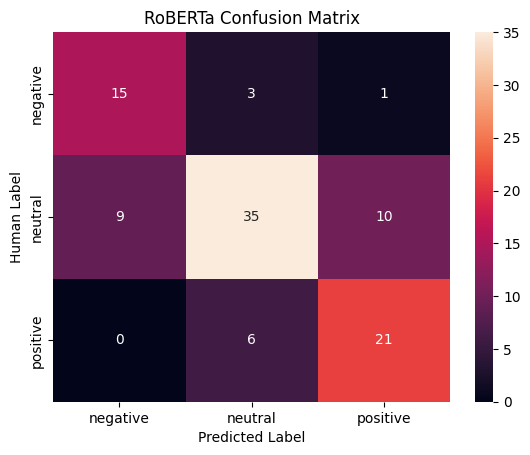

In [ ]:
# STEP 7: CONFUSION MATRICES
# The heatmaps visualise which sentiment classes each model confuses most.
# VADER's main failure: classifying neutral comments as positive due to
# isolated positive words even when the overall comment is neutral or mixed.
# RoBERTa's main failure: sarcasm and very short comments with no clear context.
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["negative", "neutral", "positive"]

cm_roberta = confusion_matrix(
    eval_df["human_sentiment"],
    eval_df["roberta_sentiment"],
    labels=labels
)

sns.heatmap(
    cm_roberta,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("RoBERTa Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Human Label")
plt.show()

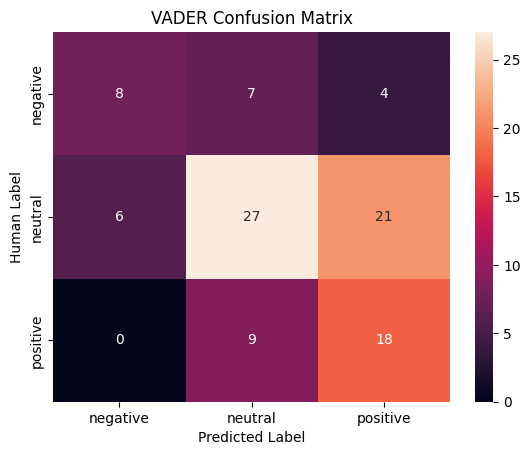

In [ ]:
cm_vader = confusion_matrix(
    eval_df["human_sentiment"],
    eval_df["vader_sentiment"],
    labels=labels
)

sns.heatmap(
    cm_vader,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("VADER Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Human Label")
plt.show()